# Building a Basic Agent with LangGraph

This notebook demonstrates how to build a simple financial assistant agent using **LangGraph**.
The agent can:
1.  Use tools to calculate loan payments, ROI, and percentages.
2.  Convert currency using an external API.
3.  Intelligently routing questions to the correct tool.
4.  Maintain state (chat history).

In [ ]:
# Installation
%pip install --pre -U langchain langchain-openai langchain-Groq Langgraph python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.1/158.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.3/496.3 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.8
    Uninstalling langchain-core-1.2.8:
      Successfully uninstalled langchain-core-1.2.8
  Attempting uninstall: Langgraph
    Found existing installation: langgraph 1.0.7
    Uninstalling langgraph-1.0.7:
      Successfully uninstalled langgraph-1.0.7
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.8
    Uninstalling langchain-1.2.8:
      Successfully uninstalled langchain-1.2.8


In [ ]:
# Setup Environment Variables
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
LANGCHAIN_API_KEY = os.getenv('LANGCHAIN_API_KEY')

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY if LANGCHAIN_API_KEY else "your_langchain_api_key"
os.environ["LANGCHAIN_PROJECT"] = "basic-langgraph"

if not GROQ_API_KEY:
    print("Warning: GROQ_API_KEY not found in environment.")

## 1. Import Libraries
Import necessary modules from `langchain`, `langgraph`, and standard libraries.

In [5]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import re

## 2. Define Tools
Create Python functions that will perform specific calculations (Loan options, ROI, Currency Conversion).
Bind these tools to the LLM so it knows when and how to call them.

In [7]:
# Tools
def loan_monthly_payment(principal: float, annual_rate: float, years: int) -> float:
    """
    Calculate monthly loan payment using the amortization formula.
    """
    r = annual_rate / 12 / 100
    n = years * 12
    payment = principal * r / (1 - (1 + r) ** -n)
    return round(payment, 2)

def calc_roi(gain: float, cost: float) -> float:
    """
    Calculate Return on Investment (percentage)
    """
    return round(((gain - cost) / cost) * 100, 2)

def calc_percentage(value: float, total: float) -> float:
    """
    Calculate percentage
    """
    return round((value / total) * 100, 2)

def convert_egp_to_usd(amount: float) -> dict:
    """
    Convert EGP to USD using live exchange rate (via open.er-api.com)
    """
    url = "https://open.er-api.com/v6/latest/USD"
    data = requests.get(url).json()

    try:
        rate = data["rates"]["EGP"]
        return {
            "rate": rate,
            "converted": round(amount / rate, 2)
        }
    except Exception as e:
        return {"error": str(e)}

tools = [loan_monthly_payment, calc_roi, convert_egp_to_usd, calc_percentage]
model = ChatGroq(
    groq_api_key=GROQ_API_KEY,
    model="openai/gpt-oss-120b"
)

llm_with_tools = model.bind_tools(tools)


## 3. Define Agent Node
Create the main node of the graph. This node invokes the LLM with the current state (list of messages) and returns the response.
We define a system message to guide the agent's behavior.

In [15]:
# LLM Node
def llm_node(state:MessagesState):
  print("#" * 80)
  print("ENTERING LLM NODE")
  for message in state["messages"]:
    message.pretty_print()

  system_message = SystemMessage(
      content=(
          """
You are a financial assistant.
Extract numbers from the question, use the correct tool for each calculation, then give a clear final answer with a simple financial explanation.
"""
      )
  )

  messages = [system_message] + state["messages"]
  response = llm_with_tools.invoke(messages)

  print("#" * 80)
  print("LEAVING LLM NODE")
  response.pretty_print()

  return {"messages": [response]}

## 4. Build the Graph
Construct the state graph:
1.  **Nodes**: Add the LLM node and a predefined `ToolNode`.
2.  **Edges**: Connect start to LLM, LLM to Tools (conditional), and Tools back to LLM.
3.  **Compile**: Compile the graph to make it executable.

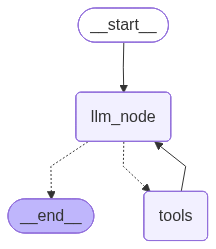

In [16]:
# build graph
builder = StateGraph(MessagesState)

builder.add_node("llm_node", llm_node)
builder.add_node("tools",ToolNode(tools=tools))

builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node",tools_condition)
builder.add_edge("tools","llm_node")

graph = builder.compile()
graph

## 5. Execution & Verification
Test the agent with various financial questions.
We also perform manual calculations to verify the agent's accuracy.

In [17]:
result = graph.invoke({
    "messages": [
        HumanMessage(
            content="I took a loan of 1,500,000 EGP for 5 years with 12% interest. What is my monthly payment?"
            )
    ]
})

################################################################################
ENTERING LLM NODE
================================ Human Message =================================

I took a loan of 1,500,000 EGP for 5 years with 12% interest. What is my monthly payment?
################################################################################
LEAVING LLM NODE
================================== Ai Message ==================================
Tool Calls:
  loan_monthly_payment (fc_a9ce4244-5681-4a91-b646-757c279683a1)
 Call ID: fc_a9ce4244-5681-4a91-b646-757c279683a1
  Args:
    annual_rate: 12
    principal: 1500000
    years: 5
################################################################################
ENTERING LLM NODE
================================ Human Message =================================

I took a loan of 1,500,000 EGP for 5 years with 12% interest. What is my monthly payment?
================================== Ai Message ==================================
Tool Ca

In [18]:
result = loan_monthly_payment(
    principal=1500000,
    annual_rate=12,
    years=5
)

print("Monthly Payment:", result)

Monthly Payment: 33366.67


In [19]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="""
        If I take a 1,200,000 EGP loan for 7 years at 13% interest, what is my monthly payment?
If I instead invest 1,200,000 and sell the project for 1,950,000 EGP, calculate the ROI, the profit percentage.
Finally, based on your knowledge, is investing generally better than taking a loan in Egypt’s current economy?
""")
    ]
})


################################################################################
ENTERING LLM NODE
================================ Human Message =================================


        If I take a 1,200,000 EGP loan for 7 years at 13% interest, what is my monthly payment?
If I instead invest 1,200,000 and sell the project for 1,950,000 EGP, calculate the ROI, the profit percentage.
Finally, based on your knowledge, is investing generally better than taking a loan in Egypt’s current economy?

################################################################################
LEAVING LLM NODE
================================== Ai Message ==================================
Tool Calls:
  loan_monthly_payment (fc_23c3df0b-a3da-42ce-8fd7-0885edd3fc89)
 Call ID: fc_23c3df0b-a3da-42ce-8fd7-0885edd3fc89
  Args:
    annual_rate: 13
    principal: 1200000
    years: 7
################################################################################
ENTERING LLM NODE
=============================

In [20]:
result = loan_monthly_payment(
    principal=1200000,
    annual_rate=13,
    years=7
)

print(result)

21830.36


In [21]:
result = calc_roi(
    gain=1950000,
    cost=1200000
)

print(result)

62.5


In [22]:
result = calc_percentage(
    value=1950000,
    total=1200000
)

print(result)

162.5


In [23]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="""
If I take a 1,600,000 EGP loan for 5 years at 18% interest, what is my monthly payment?
Then convert that monthly payment amount into USD using the latest exchange rate.
""")
    ]
})

################################################################################
ENTERING LLM NODE
================================ Human Message =================================


If I take a 1,600,000 EGP loan for 5 years at 18% interest, what is my monthly payment?
Then convert that monthly payment amount into USD using the latest exchange rate.

################################################################################
LEAVING LLM NODE
================================== Ai Message ==================================
Tool Calls:
  loan_monthly_payment (fc_79990ae3-78a5-45e5-b56d-e1ed761d857c)
 Call ID: fc_79990ae3-78a5-45e5-b56d-e1ed761d857c
  Args:
    annual_rate: 18
    principal: 1600000
    years: 5
################################################################################
ENTERING LLM NODE
================================ Human Message =================================


If I take a 1,600,000 EGP loan for 5 years at 18% interest, what is my monthly payment?
Then co

In [25]:
def get_final_answer(result):
    last_msg = result["messages"][-1]
    return last_msg.content if hasattr(last_msg, "content") else last_msg

print(get_final_answer(result))

**Monthly payment (EGP):** ≈ 40,629.48 EGP  

**Converted to USD (using the latest rate ≈ 46.8777 EGP/USD):** ≈ $866.71  

**Explanation:**  
The loan amortization formula gives a fixed monthly payment that covers both interest and principal over 5 years at an 18 % annual rate. Converting that payment with the current exchange rate shows the cost in U.S. dollars.


In [26]:
result = graph.invoke({
    "messages": [
        HumanMessage(content="""
What is your name ?
""")
    ]
})

################################################################################
ENTERING LLM NODE
================================ Human Message =================================


What is your name ?

################################################################################
LEAVING LLM NODE
================================== Ai Message ==================================

I’m ChatGPT, your financial assistant. How can I help you with your financial questions today?
